In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score



In [ ]:

data = pd.read_csv("health_lifestyle_classification.csv")

In [ ]:
print("Shape:", data.shape)
print(data.head())

Shape: (43560, 48)
   survey_code  age  gender      height     weight        bmi  bmi_estimated  \
0            1   56    Male  173.416872  56.886640  18.915925      18.915925   
1            2   69  Female  163.207380  97.799859  36.716278      36.716278   
2            3   46    Male  177.281966  80.687562  25.673050      25.673050   
3            4   32  Female  172.101255  63.142868  21.318480      21.318480   
4            5   60  Female  163.608816  40.000000  14.943302      14.943302   

   bmi_scaled  bmi_corrected  waist_size  ...  sunlight_exposure  \
0   56.747776      18.989117   72.165130  ...               High   
1  110.148833      36.511417   85.598889  ...               High   
2   77.019151      25.587429   90.295030  ...               High   
3   63.955440      21.177109  100.504211  ...               High   
4   44.829907      14.844299   69.021150  ...               High   

   meals_per_day  caffeine_intake  family_history  pet_owner  \
0            5.0         Mo

In [ ]:
# algorithm_selection_fixed.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset
df = pd.read_csv("health_lifestyle_classification.csv")

# 2. Check and handle missing values
print("Missing values per column before cleaning:\n", df.isnull().sum())

# Fill missing values (numeric → median, categorical → mode)
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# 3. Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# 4. Automatically detect target column (assuming it's the last one)
target_col = df.columns[-1]
print(f"\nDetected target column: {target_col}\n")

X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature scaling (for KNN only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define models (KNN & Decision Tree)
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 8. Train and evaluate each model
for name, model in models.items():
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    print(f"\n=== {name} Model ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Missing values per column before cleaning:
 survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               3373
heart_rate                   6113
cholesterol                     0
glucose                         1
insulin                      6906
sleep_hours                     1
sleep_quality                   1
work_hours                      1
physical_activity               1
daily_steps                  3688
calorie_intake                  1
sugar_intake                    1
alcohol_consumption         18346
smoking_level                   1
water_intake                    1
screen_time                     1
stress_level                    1
mental_health_score             1
ment

Detected target column: target

=== KNN Model ===
Accuracy: 0.6391
Confusion Matrix:
 [[ 426 2159]
 [ 985 5142]]
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.16      0.21      2585
           1       0.70      0.84      0.77      6127

    accuracy                           0.64      8712
   macro avg       0.50      0.50      0.49      8712
weighted avg       0.58      0.64      0.60      8712



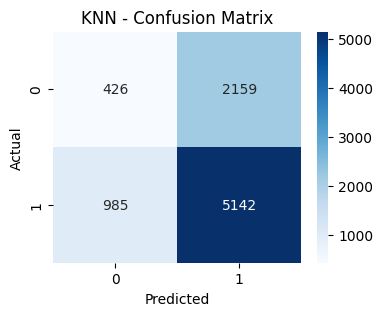


=== Decision Tree Model ===
Accuracy: 0.586
Confusion Matrix:
 [[ 807 1778]
 [1829 4298]]
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.31      0.31      2585
           1       0.71      0.70      0.70      6127

    accuracy                           0.59      8712
   macro avg       0.51      0.51      0.51      8712
weighted avg       0.59      0.59      0.59      8712



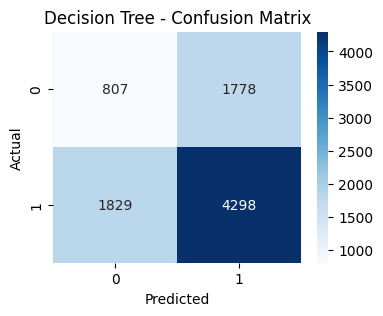

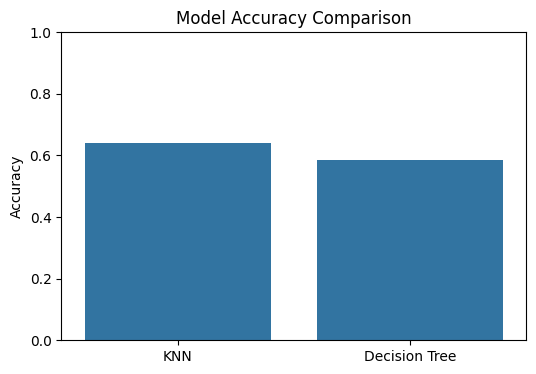

In [ ]:
# model_implementation.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("health_lifestyle_classification.csv")

# 2. Handle missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# 3. Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# 4. Automatically detect target column (assumes last column)
target_col = df.columns[-1]
print(f"Detected target column: {target_col}")

X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 8. Train, predict, and evaluate
results = {}

for name, model in models.items():
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n=== {name} Model ===")
    print("Accuracy:", round(acc, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 9. Compare Model Performance
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


In [ ]:
# hyperparameter_tuning_knn.py

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset
df = pd.read_csv("health_lifestyle_classification.csv")

# 2. Handle missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# 3. Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# 4. Detect target column automatically
target_col = df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Scale features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define KNN model and hyperparameter grid
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 8. Perform Grid Search
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)

# 9. Display best parameters
print("\nBest Parameters for KNN:", grid_knn.best_params_)
print("Best KNN Accuracy (Cross-Validation):", round(grid_knn.best_score_, 4))

# 10. Evaluate tuned KNN model on test set
best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("\n=== Tuned KNN Model Evaluation ===")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Best Parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best KNN Accuracy (Cross-Validation): 0.6748

=== Tuned KNN Model Evaluation ===
Test Accuracy: 0.6736
Confusion Matrix:
 [[ 213 2372]
 [ 472 5655]]
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.08      0.13      2585
           1       0.70      0.92      0.80      6127

    accuracy                           0.67      8712
   macro avg       0.51      0.50      0.46      8712
weighted avg       0.59      0.67      0.60      8712




=== KNN (Tuned) ===
Accuracy: 0.6525
Precision: 0.585
Recall: 0.6525
F1 Score: 0.6024
Confusion Matrix:
 [[ 339 2246]
 [ 781 5346]]
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.13      0.18      2585
           1       0.70      0.87      0.78      6127

    accuracy                           0.65      8712
   macro avg       0.50      0.50      0.48      8712
weighted avg       0.59      0.65      0.60      8712



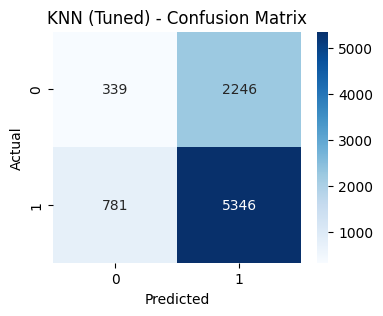


=== Decision Tree ===
Accuracy: 0.6957
Precision: 0.5747
Recall: 0.6957
F1 Score: 0.5849
Confusion Matrix:
 [[  39 2546]
 [ 105 6022]]
Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.02      0.03      2585
           1       0.70      0.98      0.82      6127

    accuracy                           0.70      8712
   macro avg       0.49      0.50      0.42      8712
weighted avg       0.57      0.70      0.58      8712



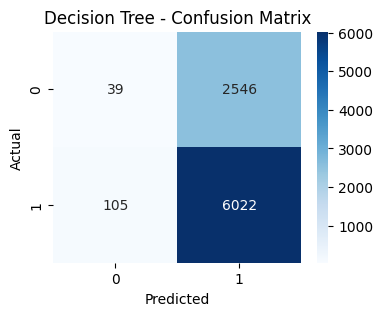


Cross-Validation Results (5-Fold):
KNN (Tuned): Mean CV Accuracy = 0.6540 ± 0.0022
Decision Tree: Mean CV Accuracy = 0.6997 ± 0.0028


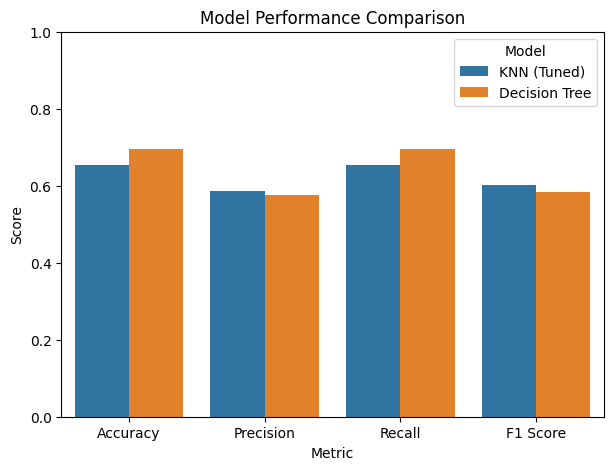

In [ ]:
# model_evaluation_comparison.py

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("health_lifestyle_classification.csv")

# 2. Handle missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# 3. Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# 4. Detect target column
target_col = df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define tuned KNN (based on your previous tuning results)
best_knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan')

# 8. Define Decision Tree for comparison
dt = DecisionTreeClassifier(max_depth=7, min_samples_split=5, min_samples_leaf=2, random_state=42)

# 9. Train models
best_knn.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)

# 10. Predict and evaluate
models = {
    "KNN (Tuned)": (best_knn, X_test_scaled),
    "Decision Tree": (dt, X_test)
}

results = []

for name, (model, X_test_data) in models.items():
    y_pred = model.predict(X_test_data)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 11. Cross-Validation for model stability
print("\nCross-Validation Results (5-Fold):")
for name, (model, _) in models.items():
    X_data = X_train_scaled if name.startswith("KNN") else X_train
    cv_scores = cross_val_score(model, X_data, y_train, cv=5, scoring='accuracy')
    print(f"{name}: Mean CV Accuracy = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 12. Model Comparison (Bar Chart)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

plt.figure(figsize=(7,5))
sns.barplot(data=results_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.show()


Overall Accuracy: 0.6403

Ethical Bias (Fairness) Analysis
   gender  Group_Accuracy
0       0        0.643436
1       1        0.636998


/tmp/ipython-input-3674671566.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["Actual"], x["Predicted"]))
/tmp/ipython-input-3674671566.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sensitive_feature, y="Group_Accuracy", data=bias_results, palette="Set2")


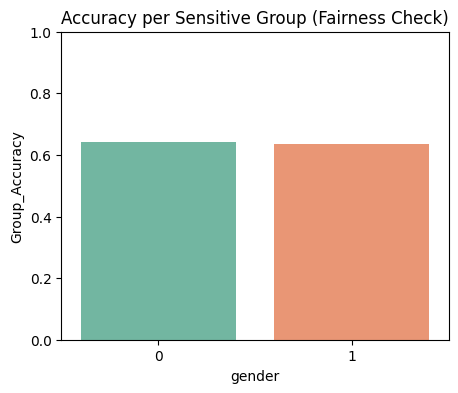


Bias Gap between groups = 0.0064
Model appears fairly balanced between groups.


In [8]:
# ethical_bias_analysis

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("health_lifestyle_classification.csv")

# 2. Handle missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# 3. Encode categorical variables
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# 4. Detect target column
target_col = df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train tuned KNN model
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan')
knn.fit(X_train_scaled, y_train)

# 8. Predict
y_pred = knn.predict(X_test_scaled)

# 9. Basic accuracy
print("Overall Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# 10. Ethical Bias Detection
# -----------------------------------------------------
# Choose a sensitive attribute (example: "Gender" or "Age")
# Replace with the correct column name from your dataset
sensitive_feature = "gender"  # Change if your dataset uses a different name

if sensitive_feature in df.columns:
    # Recreate test subset with this feature
    test_data = X_test.copy()
    # Add the sensitive feature column back to test_data from the original X_test
    test_data[sensitive_feature] = X_test[sensitive_feature]
    test_data["Actual"] = y_test
    test_data["Predicted"] = y_pred

    # Group accuracy by sensitive attribute
    bias_results = (
        test_data.groupby(sensitive_feature)
        .apply(lambda x: accuracy_score(x["Actual"], x["Predicted"]))
        .reset_index(name="Group_Accuracy")
    )

    print("\nEthical Bias (Fairness) Analysis")
    print(bias_results)

    # Visualize bias (accuracy difference between groups)
    plt.figure(figsize=(5,4))
    sns.barplot(x=sensitive_feature, y="Group_Accuracy", data=bias_results, palette="Set2")
    plt.title("Accuracy per Sensitive Group (Fairness Check)")
    plt.ylim(0,1)
    plt.show()

    # Difference between best and worst group
    bias_gap = bias_results["Group_Accuracy"].max() - bias_results["Group_Accuracy"].min()
    print(f"\nBias Gap between groups = {bias_gap:.4f}")
    if bias_gap > 0.10:
        print("Warning: Model shows potential bias between groups!")
    else:
        print("Model appears fairly balanced between groups.")
else:
    print(f"Sensitive attribute '{sensitive_feature}' not found in dataset.")